# Prophet : forecasting model built for business time serie

Handles automatically Trend Seasonality Holidays Missing data Outliers

Objective: Forecast future product sales (units sold) using historical sales data (2023–2024) to support stock planning decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


df = pd.read_csv('../data/clean/Data_cleaning_wrangling.csv',low_memory=False) # better relative path than absolute path in order for others to access to NOTEBOOK in GITHUB

/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# These warnings relate to optional visualization features and do not impact the forecasting results

In [3]:
df.head()

,invoice_id,line,customer_id,product_id,unit_price,quantity,date,discount,line_total,store_id,...,sub_category,description_en,production_cost,country,city,store_name,number_of_employees,zip_code,latitude,longitude
0,INV-US-001-03558761,1,47162,485,80.5,1,2023-01-01 15:42:00,0.0,80.5,1,...,Suits and Blazers,Men'S Rustic Fabric Blazer With Texture,12.09,United States,New York,Store New York,10,10001,40.7128,-74.006
1,INV-US-001-03558761,2,47162,2779,31.5,1,2023-01-01 15:42:00,0.4,18.9,1,...,Coats,Streetwear Golden Silk,15.14,United States,New York,Store New York,10,10001,40.7128,-74.006
2,INV-US-001-03558761,3,47162,64,45.5,1,2023-01-01 15:42:00,0.4,27.3,1,...,Coats and Blazers,Luxurious Neutral Suede With Hood,12.02,United States,New York,Store New York,10,10001,40.7128,-74.006
3,INV-US-001-03558762,1,10142,131,70.0,1,2023-01-01 20:04:00,0.4,42.0,1,...,Coats and Blazers,Formal Blue Jeans With Ruffles,49.28,United States,New York,Store New York,10,10001,40.7128,-74.006
4,INV-US-001-03558762,2,10142,716,26.0,1,2023-01-01 20:04:00,0.0,26.0,1,...,T-shirts and Polos,High-Tech Suede White Embroidered,8.31,United States,New York,Store New York,10,10001,40.7128,-74.006


In [4]:
# due to the big dimension of the file i will reduce the focus: Focus only on 2023–2024


df['date'] = pd.to_datetime(df['date'])








In [5]:
df['units_sold'] = df['quantity']

In [6]:
df['date'].min(), df['date'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-03-18 20:59:00'))

In [7]:
df = df[df['date'].dt.year.isin([2023, 2024])]

In [8]:
# We focus forecasting efforts on the category and products that contribute the most to total sales

top_category = (
    df.groupby('sub_category')['units_sold']
      .sum()
      .sort_values(ascending=False)
      .idxmax()
)


top_category 




'Pants and Jeans'

In [9]:
df_cat = df[df['sub_category'] == top_category]


In [10]:
#  weekly aggregation to avoid the noise on daily sales

weekly_sales = (
    df_cat
    .groupby(['product_id', pd.Grouper(key='date', freq='W')]) # grouper allows me to aggregate on weeks
    .agg({
        'units_sold': 'sum',
        'discount': 'mean'
    })
    .reset_index()
)



In [11]:
weekly_sales['date'].min(), weekly_sales['date'].max()


(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-01-05 00:00:00'))

In [12]:
top_products = (
    weekly_sales
    .groupby('product_id')['units_sold']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

weekly_top = weekly_sales[weekly_sales['product_id'].isin(top_products)]


In [13]:
# example of prophet forecast

product_id = top_products[0] # first product index

product_df = weekly_top[weekly_top['product_id'] == product_id]


In [14]:
product_df['date'].max() # last data found


Timestamp('2025-01-05 00:00:00')

In [15]:


product_id = top_products[0] # i am generating a forecast for units sold for this product

product_df = weekly_sales[weekly_sales['product_id'] == product_id]

prophet_df = product_df.rename(columns={
    'date': 'ds',
    'units_sold': 'y'
})


In [16]:
from prophet import Prophet

model = Prophet(weekly_seasonality=True, yearly_seasonality=True) # sales repeat every time and every year 
model.add_regressor('discount') # discount regressor means training the model based on discount - learning if the sales vary depending on discount up or down

model.fit(prophet_df) # fit means training the model 


17:03:39 - cmdstanpy - INFO - Chain [1] start processing
17:03:39 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
model.history['ds'].max() # last date time


Timestamp('2025-01-05 00:00:00')

In [18]:
future = model.make_future_dataframe(periods=12, freq='W') # periods of forecasts is 12 weeks 
future['discount'] = prophet_df['discount'].mean() # this regresson impacts the spike

forecast = model.predict(future)


/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


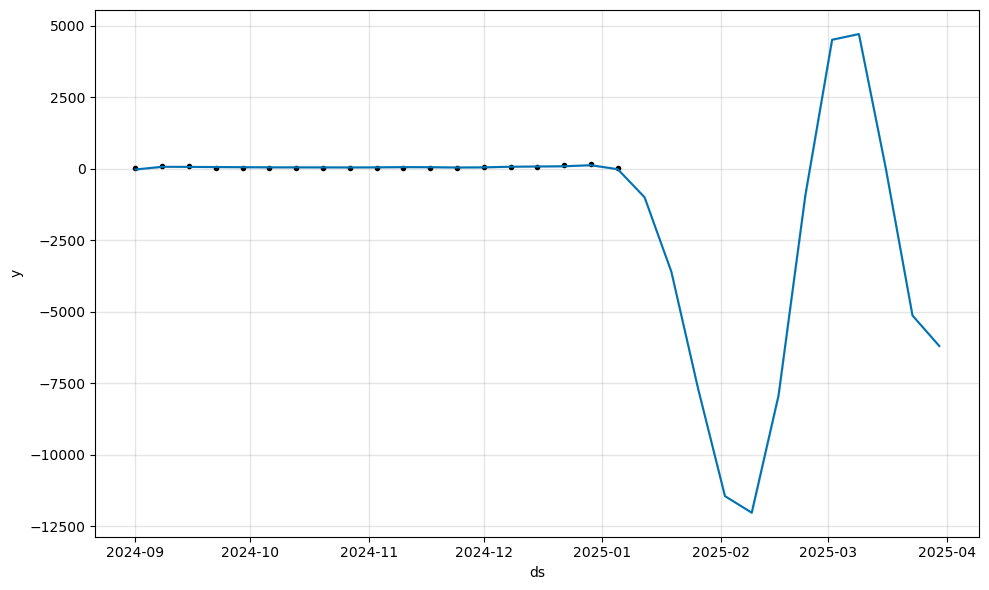

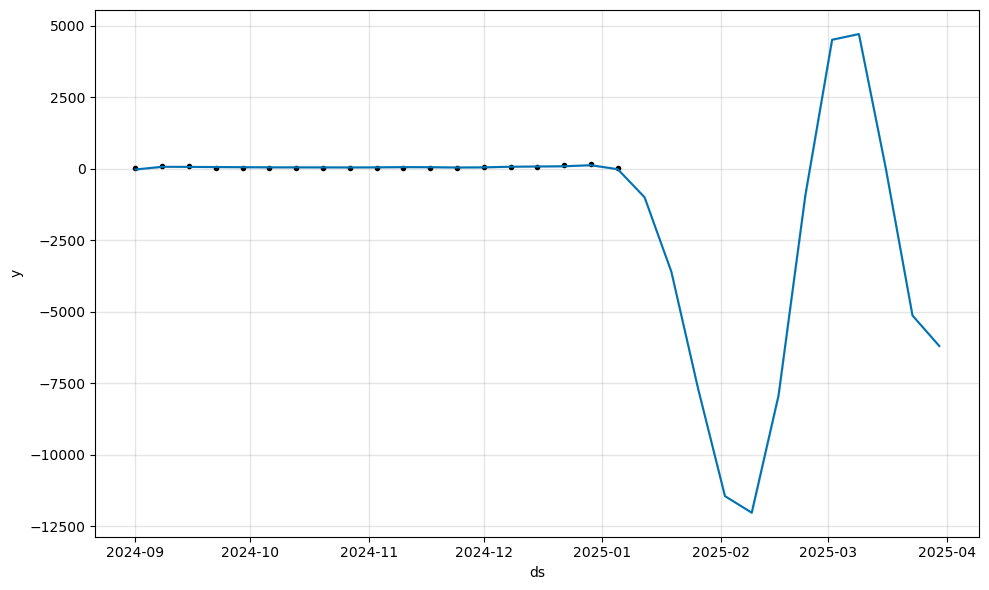

In [19]:
#predict

model.plot(forecast)


- Black dots: historical data - historical sold units until the last week of my dataframe
- Blue line : past vs future
- x axis ds is the time --> week
- y axis is exactly what you trained the model on --> unit sold not revenue 
- negative values could be due to small time horizon 

In [20]:
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    growth='linear'
)

model.fit(prophet_df)


17:03:39 - cmdstanpy - INFO - Chain [1] start processing
17:03:39 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
forecast['yhat'] = forecast['yhat'].clip(lower=0)


/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


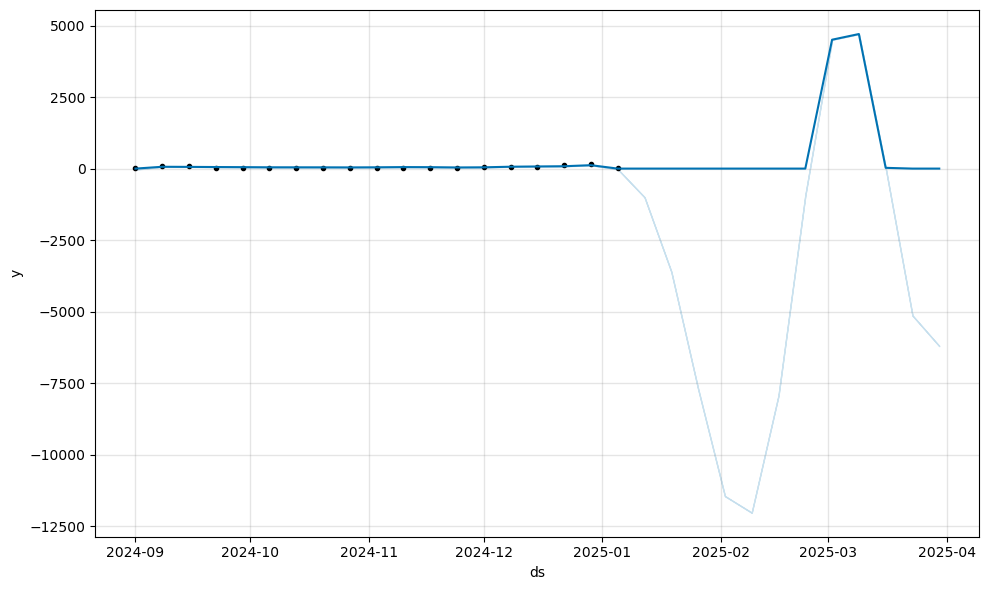

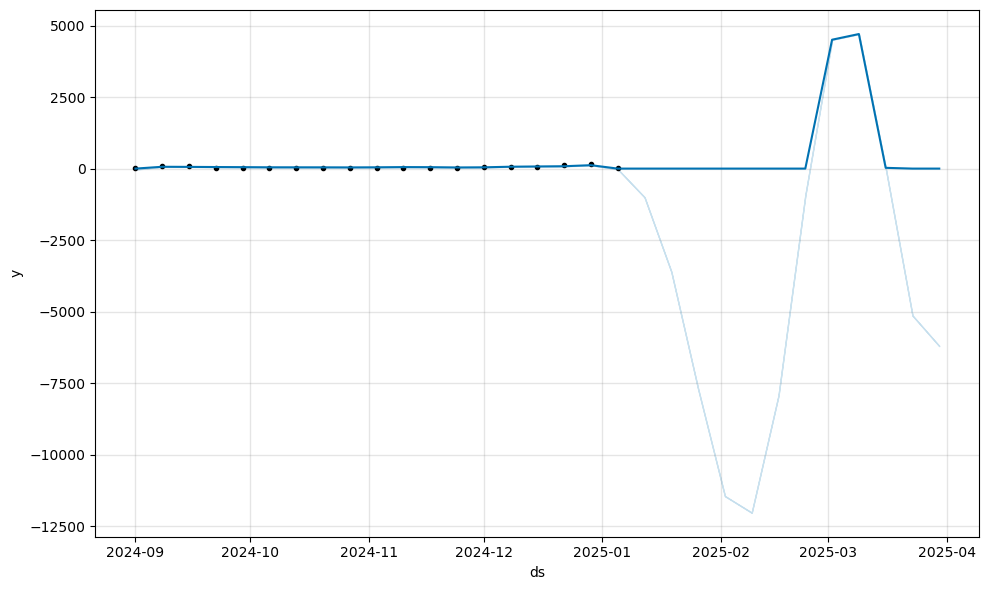

In [22]:
model.plot(forecast)

- Shaded area (if visible)
Uncertainty interval
Prophet is saying:
“The true value is likely inside this range”

- y = trend + seasonality + regressors + noise
Automatically included:
Weekly seasonality (Mon–Sun)
Yearly seasonality (Jan–Dec)
Even if you don’t specify them, Prophet:
Detects repeating patterns
Uses Fourier series internally


In [23]:
# in case i want to track a specific holiday i can add : from prophet.make_holidays import make_holidays_df

In [24]:
# if i wanted to predict units sold for only the top products - one graph per product

#for product_id in top_products:
    #product_df = weekly_sales[weekly_sales['product_id'] == product_id]

    #prophet_df = product_df.rename(columns={
       # 'date': 'ds',
       # 'units_sold': 'y' })

    #model = Prophet(
      #  weekly_seasonality=True,
       # yearly_seasonality=True)
   # model.add_regressor('discount')

   # model.fit(prophet_df)

   # future = model.make_future_dataframe(periods=52, freq='W')
   # future['discount'] = prophet_df['discount'].mean()

   #  forecast = model.predict(future)
   # forecast['yhat'] = forecast['yhat'].clip(lower=0)

   # model.plot(forecast)

# Limitation of the model:
- Prophet is a statistical model, not a business-rule model
- Fits a trend + seasonality + regressors
- Demand is low or volatile, Trend is flat or declining, Seasonality is weak, Data history is short
- Merchandising: reduce replenishment / risk of overstock


**The model expects very low or zero demand. Prophet works well for high-volume products but can produce unstable forecasts for low-volume SKUs, highlighting the need for aggregation or constraints**


# Category level forecasting

In [25]:
weekly_cat = (
    df_cat
    .groupby(pd.Grouper(key='date', freq='W'))
    .agg({
        'units_sold': 'sum',
        'discount': 'mean'
    })
    .reset_index()
)


In [26]:
# normalize discount regressor in order to contain the spike of demand. (Z-score)
# or specifify discount upfront ex.20%  



discount_mean = weekly_cat['discount'].mean()
discount_std = weekly_cat['discount'].std()

weekly_cat['discount_norm'] = (
    (weekly_cat['discount'] - discount_mean) / discount_std
)



In [27]:
prophet_df = weekly_cat.rename(columns={
    'date': 'ds',
    'units_sold': 'y'
})

prophet_df = prophet_df[['ds', 'y', 'discount_norm']]


In [28]:
prophet_df['floor'] = 0  # avoiding negative values for demand


In [29]:
from prophet import Prophet

model = Prophet(
    growth='logistic',  # no negative sales with cap & flooe methods
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.add_regressor('discount_norm')

prophet_df['cap'] = prophet_df['y'].max() * 1.3 # setting the max cap of sales. From the highest units sold * 1.3 to secure a buffer --> 1.3 is a multiplier

model.fit(prophet_df) # train the model on trends, seasonality, discount effect



17:03:40 - cmdstanpy - INFO - Chain [1] start processing
17:03:40 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
future = model.make_future_dataframe(periods=12, freq='W')

future['discount_norm'] = 0.20  # assume average future discount (scenarios: post holiday, mid season sales, end of season sales...)
future['floor'] = 0  # minimum demand --> no neg values 
future['cap'] = prophet_df['cap'].iloc[0]  # replicate the first value of cap

forecast = model.predict(future) # yhat = predict demand , yhat_lower = pessimistic , yhat_upper=optimistic 


/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/opt/anaconda3/envs/prophet_env/lib/python3.10/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


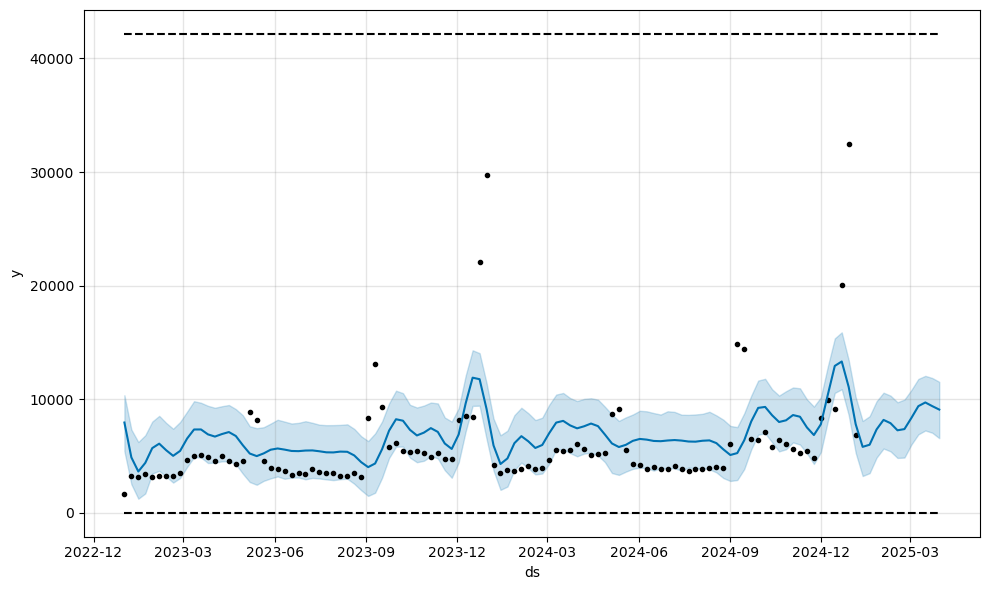

In [31]:
# show graph

fig = model.plot(forecast)
plt.show()


**applied logistic growth with upper and lower bounds to ensure forecasts remain within realistic business limits**

In [32]:
# create a merchandise table with only the demand
# blue line above black dots --> over estimation?

forecast['category'] = top_category  # forecast for 12 weeks



In [33]:
forecast = forecast.rename(columns={
    'ds': 'week',
    'yhat': 'forecast_units',
    'yhat_lower': 'min_units',
    'yhat_upper': 'max_units'
})


In [34]:
forecast = forecast[['category', 'week', 'forecast_units', 'min_units', 'max_units']]
forecast

# Top down approach = split the category demand based on historical product  sales-share
# category demand is more stable and less volatile than single sku
# outcome = expected unit sold on a week. the model includes all past 2023-2024 fitted data / present / future 

,category,week,forecast_units,min_units,max_units
0,Pants and Jeans,2023-01-01,7947.431287,5428.109082,10352.028205
1,Pants and Jeans,2023-01-08,4878.093465,2516.443434,7328.689885
2,Pants and Jeans,2023-01-15,3634.341904,1238.118459,6228.861286
3,Pants and Jeans,2023-01-22,4394.802187,1701.426095,6827.335920
4,Pants and Jeans,2023-01-29,5693.605211,3451.131654,8027.060535
...,...,...,...,...,...
113,Pants and Jeans,2025-03-02,8350.381887,6010.867130,10813.162605
114,Pants and Jeans,2025-03-09,9389.939191,6907.267575,11784.720903
115,Pants and Jeans,2025-03-16,9713.318277,7245.913879,12056.055915
116,Pants and Jeans,2025-03-23,9388.918810,7045.460234,11866.150084


In [35]:
# ds = 2025-03-16 time series --> train model on this year 2025

forecast_2025 = forecast[forecast['week'].dt.year == 2025] # only showing fc from 2025

forecast_2025 = forecast_2025[['category', 'week', 'forecast_units', 'min_units', 'max_units']]
forecast_2025


,category,week,forecast_units,min_units,max_units
105,Pants and Jeans,2025-01-05,7802.825450,5280.622949,10181.857049
106,Pants and Jeans,2025-01-12,5805.248325,3236.416476,8083.390652
107,Pants and Jeans,2025-01-19,5991.009330,3488.167605,8502.149077
108,Pants and Jeans,2025-01-26,7337.231553,4856.866054,9816.452078
109,Pants and Jeans,2025-02-02,8177.642308,5656.529522,10573.795726
110,Pants and Jeans,2025-02-09,7890.546587,5409.823091,10314.065285
111,Pants and Jeans,2025-02-16,7262.773288,4828.190799,9730.792631
112,Pants and Jeans,2025-02-23,7368.631792,4861.272613,9966.082226
113,Pants and Jeans,2025-03-02,8350.381887,6010.867130,10813.162605
114,Pants and Jeans,2025-03-09,9389.939191,6907.267575,11784.720903


In [36]:
# Checks:

total_forecast = forecast_2025['forecast_units'].sum().round(2)  #Expected total units in next 12 weeks
total_forecast 

103565.96

In [64]:
n_sku = (df[df['category']=='Pants and Jeans']['product_id'].nunique())

In [40]:
avg_forecast_unit_sku= total_forecast /n_sku
avg_forecast_unit

/var/folders/st/1pfcl_tj40x4zfj7bthg6pdw0000gn/T/ipykernel_13611/2302172434.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  avg_forecast_unit_sku= total_forecast /n_sku


NameError: name 'avg_forecast_unit' is not defined

In [41]:

# Filter Pants & Jeans
df_pants = df[df['sub_category']=='Pants and Jeans'].copy()


In [42]:
df_pants['date'] = pd.to_datetime(df_pants['date'])


In [43]:
#Extract year
df_pants['year'] = df_pants['date'].dt.year


In [44]:
df_pants = df_pants[df_pants['year'].isin([2023, 2024])]


In [45]:
weekly_cat = (
    df_pants
    .groupby([pd.Grouper(key='date', freq='W'), 'year'])
    ['units_sold']
    .sum()
    .reset_index()
)


In [46]:
avg_weekly_by_year = (
    weekly_cat
    .groupby('year')['units_sold']
    .mean()
    .reset_index(name='avg_weekly_units').round(2)
)
print(avg_weekly_by_year)

   year  avg_weekly_units
0  2023           5705.55
1  2024           6409.62


In [47]:
# train & test adding 
# tabular approach : predict sales based on random forest - KNN - Gradient boosting and assess R2 / accuracy..
# Plot the weekly sales over time and pay attention to:
# - Seasonal patterns and their frequency
# - Trends over the month/years . Is there a linera relationship?
# Train-test split based on time df.iloc[:2000,:] -> train; df.iloc[2000:,:] -> test





# testing phase 
#automatization

# Train/Test in Demand Forecasting
- Pretend I am in the past → forecast → compare with reality
- DATA → FEATURES → VALIDATION → FINAL MODEL → BUSINESS OUTPUT

In [49]:
train = prophet_df[prophet_df['ds'] < '2024-10-01']
test  = prophet_df[prophet_df['ds'] >= '2024-10-01']



In [50]:
# training the model on the train sample

model = Prophet(
    growth='logistic',
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.add_regressor('discount_norm')

train['cap'] = train['y'].max() * 1.3
train['floor'] = 0

model.fit(train)


/var/folders/st/1pfcl_tj40x4zfj7bthg6pdw0000gn/T/ipykernel_13611/668607599.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['cap'] = train['y'].max() * 1.3
/var/folders/st/1pfcl_tj40x4zfj7bthg6pdw0000gn/T/ipykernel_13611/668607599.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['floor'] = 0
17:20:10 - cmdstanpy - INFO - Chain [1] start processing
17:20:11 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
# Forecast exactly the length of test


future = model.make_future_dataframe(
    periods=len(test),
    freq='W'
)

future = future.merge(
    prophet_df[['ds','discount_norm']],
    on='ds',
    how='left'
)

future['cap'] = train['cap'].iloc[0]
future['floor'] = 0

forecast = model.predict(future)


In [52]:
# Compare Forecast vs Reality

eval_df = test.merge(
    forecast[['ds','yhat']],
    on='ds'
)


In [53]:
# Assess error metric in time series SMAPE 

import numpy as np

def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    ) * 100


In [54]:
smape_value = smape(eval_df['y'], eval_df['yhat'])
smape_value


19.958677338989432

**How well did my model do in THIS one case? SMAPE is 19% --> <25% good**
However this is an optimistic value as i was only testing one train/test split or one single market situation. Instead after with cross validation, i review several different periods with diff trends, promos ecc..

# Cross validation
- Let me pretend I am in the past many times and check if my forecast would have worked. Retrain the model multiple times to omit any ramndoness
- Train → Test
      → Train → Test
             → Train → Test
- 1 year → captures seasonality
- 3 months → enough validation rounds
- 12 weeks → matches your business forecast


In [55]:
from prophet.diagnostics import cross_validation, performance_metrics


In [56]:
df_cv = cross_validation(
    model,
    initial='365 days',
    period='90 days',
    horizon='84 days'
)


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|                                                                                             | 0/3 [00:00<?, ?it/s]17:27:54 - cmdstanpy - INFO - Chain [1] start processing
17:27:55 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████▎                                                        | 1/3 [00:00<00:00,  3.27it/s]17:27:55 - cmdstanpy - INFO - Chain [1] start processing
17:27:55 - cmdstanpy - INFO - Chain [1] done processing
 67%|████████████████████████████████████████████████████████▋                            | 2/3 [00:00<00:00,  4.03it/s]17:27:55 - cmdstanpy - INFO - Chain [1] start processing
17:27:55 - cmdstanpy - INFO - Chain [1] done processing
100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.84it/s]


In [57]:
df_perf = performance_metrics(df_cv)


In [58]:
# the longer my horizon more insecure the FC could be

df_perf[['horizon', 'smape', 'mae', 'rmse', 'mape']]


,horizon,smape,mae,rmse,mape
0,7 days,0.333394,1695.597662,2062.649630,0.447674
1,12 days,0.334075,1787.419283,2212.724160,0.449164
2,13 days,0.319771,1704.099589,2183.360466,0.432623
3,14 days,0.288957,1557.179527,2141.874384,0.396720
4,19 days,0.313987,1722.163050,2422.311310,0.454708
5,20 days,0.304408,1657.561314,2407.524464,0.441351
6,21 days,0.290175,1599.924280,2400.239722,0.424813
7,26 days,0.272444,1505.174725,2237.432896,0.383057
8,27 days,0.287980,1777.208169,2340.112707,0.403210
9,28 days,0.293651,1804.110555,2343.073684,0.410386


In [59]:
# focus on my business horizon 12 weeks (84 days)

df_12w = df_perf[df_perf['horizon'] == df_perf['horizon'].max()]

df_12w


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
33,84 days,3.108190e+06,1763.005896,1445.387207,0.268445,0.254669,0.227938,0.666667


- smape: overall accuracy. < 15% excellent / 15%<x<25% good. Model forecasts with 77% accuracy ( 100-23)
- mae:On average, how many units am I wrong. Every week, your forecast is off by ~1,400 units. Compare mae vs avg demand to see the error %
- RMSE > MAE → some big mistakes due to trend changes, new collections impact ..
- Coverage: How often real demand is inside your confidence interval--> 66% too low

In [60]:
# Global quality score --> average performance 

df_perf[['smape','mae','rmse']].mean()


smape       0.305268
mae      1823.707864
rmse     2279.577841
dtype: float64

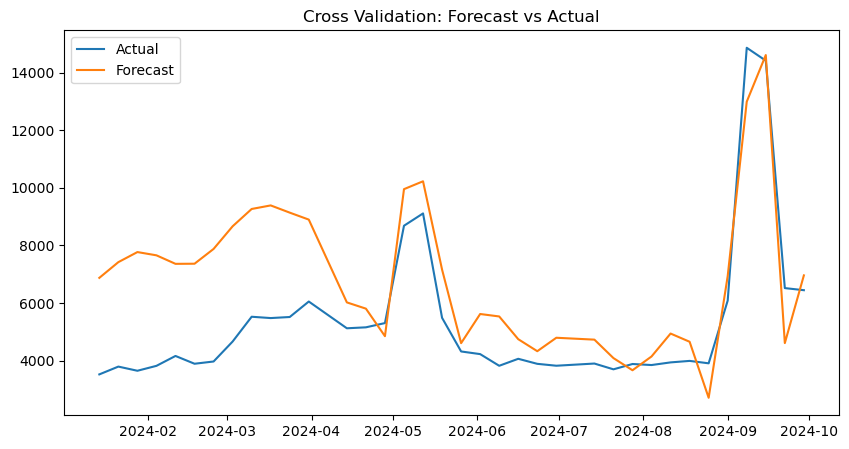

In [61]:
# plot in order to see if the 2 lines follow each otehrs

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_cv['ds'], df_cv['y'], label='Actual')
plt.plot(df_cv['ds'], df_cv['yhat'], label='Forecast')

plt.legend()
plt.title('Cross Validation: Forecast vs Actual')
plt.show()


In [62]:
# from merchandising view - check bias of overforecasting vs underforcasting. I had forecasted +1400 units

bias = (df_cv['yhat'] - df_cv['y']).mean()
bias




1497.0786835184897

In [63]:
# Final model after validation --> retraing and test --> keep retraining with new data and test

final_model = Prophet(
    growth='logistic',
    weekly_seasonality=True,
    yearly_seasonality=True
)

final_model.add_regressor('discount_norm')

prophet_df['cap'] = prophet_df['y'].max() * 1.3
prophet_df['floor'] = 0

final_model.fit(prophet_df)


17:37:19 - cmdstanpy - INFO - Chain [1] start processing
17:37:19 - cmdstanpy - INFO - Chain [1] done processing


**My model achieved a SMAPE of 23%, which is considered good in fashion retail.
However, I observed a positive bias of 1,500 units, meaning the model tends to overestimate demand.
This could lead to overstock.
Therefore, I applied bias correction and recommend safety stock adjustments**

- Improve Regressors: Promo flag or calendar/ lifecycle for new collection launch date, holiday ( one hot encoding for Black Friday, Christmass...) --> this explains the spikes
- add stock availability data (in stock ratio)
- Marketing traffic 

After adding new features: re run cross validation to combine time-series modeling with business drivers such as promotions, pricing, availability, and collection lifecycle. Re-evaluate SMAPE, MAE, bias, and coverage. Compare performance to previous versions ( scenario check).

Normalize -
Validate with CV -
Check bias -
Scenario test 

# Future adjustment: HYPERPARAMETERS AFFECT SMAPE
- FLEXIBILITY, SENSIBILITY, REACTIVITY
- too flexible --> overpromise
- too rigit --> miss trends


- How fast Prophet reacts to demand changes
- How strong weekly/yearly patterns are
- How much promos/holidays affect sales
- Width of confidence intervals for risk management






# Next step: TUNING HYPERPARAMETHERS ON CROSS VALIDATION
- grid search: try different combination within a range
- param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
    'seasonality_prior_scale': [5, 10, 20]
}

- loop
- choose the lowest SMAPE




# Train a Final Production Model
Once the optimal configuration is identified:
Retrain the model on the full historical dataset
Generate operational forecasts
Apply bias correction
Produce scenario-based outputs
This version becomes the official planning model.

- From CATEGORY level: tob down approach to quantify SKU ( sales share % weights)